In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.sparse.linalg import expm_multiply, expm
from scipy.sparse import diags
from utils import *
from ionq_circuit_utils import *

from os import getenv
from os.path import join
import json

import networkx as nx
from random import shuffle, seed

import requests

from dotenv import load_dotenv
load_dotenv()


True

Ground truth w/ high resolution

In [2]:
def get_H_d_dim(n : int, d : int, dx, c=1):
    H_1D = np.zeros((n,n), dtype=np.complex128)

    for i in range(n):
        H_1D[i, (i+1) % n] = -1j
        H_1D[(i+1) % n, i] = 1j
    H_1D *= (c / (2 * dx))
    dims = [n ** i for i in range(d)]
    return np.sum([tensor([np.identity(dims[d-i-1]), H_1D, np.identity(dims[i])]) for i in range(d)])

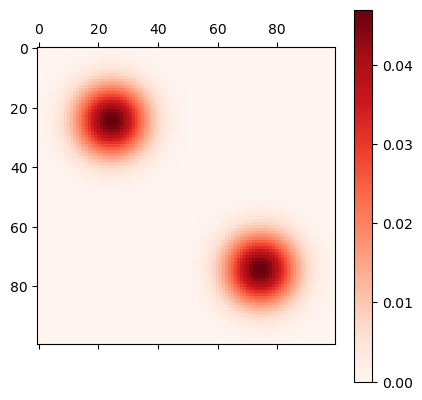

In [3]:
N_high_res = 100
dimension = 2
c = 1
T = 0.2
num_time_points = 5
t_vals = np.linspace(0, T, num_time_points)


psi_0_2d = np.zeros((N_high_res,N_high_res))
# theta = 0.5#np.pi/4
# assert theta <= np.pi/4
width = N_high_res // 4
sigma = 0.08
gaussian = np.exp(-0.5 * ((np.arange(-width, width) / (N_high_res-1)) / sigma) ** 2)
gaussian /= np.linalg.norm(gaussian)


for mean in [N_high_res // 4 - 1, 3 * N_high_res // 4 - 1]:
    psi_0_2d[mean,mean] = 1
    psi_0_2d[mean+1,mean] = 1
    psi_0_2d[mean,mean+1] = 1
    psi_0_2d[mean+1,mean+1] = 1
    

for mean in [N_high_res // 4 - 1, 3 * N_high_res // 4 - 1]:

    for i in range(min(width, mean, N_high_res - mean - 2)):
        theta = np.arccos(gaussian[width+i] / np.linalg.norm(gaussian[width+i:]))

        a = np.copy(psi_0_2d[:,mean+i+1])
        psi_0_2d[:,mean+i+1] = np.cos(theta) * a
        psi_0_2d[:,mean+i+2] = np.sin(theta) * a

        a = np.copy(psi_0_2d[:,mean-i])
        psi_0_2d[:,mean-i] = np.cos(theta) * a
        psi_0_2d[:,mean-i-1] = np.sin(theta) * a

    for i in range(min(width, mean, N_high_res - mean - 2)):
        theta = np.arccos(gaussian[width+i] / np.linalg.norm(gaussian[width+i:]))
        
        a = np.copy(psi_0_2d[mean+i+1,:])
        psi_0_2d[mean+i+1,:] = np.cos(theta) * a
        psi_0_2d[mean+i+2,:] = np.sin(theta) * a

        a = np.copy(psi_0_2d[mean-i,:])
        psi_0_2d[mean-i,:] = np.cos(theta) * a
        psi_0_2d[mean-i-1,:] = np.sin(theta) * a

psi_0_2d /= np.linalg.norm(psi_0_2d)

plt.matshow(psi_0_2d, cmap="Reds")
plt.colorbar()
plt.show()

In [4]:
psi_0 = psi_0_2d

psi_0 = psi_0.flatten()
psi_0 /= np.linalg.norm(psi_0)

dx = 1 / (N_high_res - 1)

H = get_H_d_dim(N_high_res, dimension, dx, c)
# H[0,-1] = 1j
# H[-1,0] = -1j

psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)

ideal_dist = np.abs(psi) ** 2
ideal_dist_reshaped = np.reshape(ideal_dist, (num_time_points, N_high_res, N_high_res))

Get ideal simulation results and real-machine results

In [7]:

job_ids_ideal_sim = [
    "cef37ccb-cf44-4305-966f-a3022cd945c7",
    "e642feb9-32bf-4011-8110-ed61d4062ce7",
    "7e15111b-d2bb-4ff4-9c5e-f03377140256",
    "10cf8430-5c78-48c9-a914-1188204e136d",
    "67f7b492-b6e7-40e9-9084-c5b1dd1470db"
]

job_ids_qpu = [
    "ccf814e2-325e-4626-b0b6-898a90f236fd",
    "cd09b70f-7591-44a6-b676-881c4b2357be",
    "e7256848-2e97-41d2-ba8f-28eb10c43d18",
    "b3782e9c-3409-4d9a-b648-fcd41c44b9be",
    "f0a99337-5b59-4608-9d99-b3eea69e4d00"
]

In [8]:
N = 10
encoding = "one-hot"
codewords = get_codewords(N, dimension, encoding)

In [9]:
def get_ionq_single_job_result(job_id, codewords, use_error_mitigation=False):
    # Get job
    print("Getting job:", job_id)

    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}"
    }

    req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}", headers=headers)
    

    status = json.loads(req.content)['status']
    print(f"Job status: {status}")
    if status == "completed":
        
        headers = {
            "Authorization": f"apiKey {IONQ_API_KEY}"
        }
        if use_error_mitigation:
            params = {"sharpen": "true"} # plural voting aggregation
        else:
            params = {"sharpen": "false"}
        req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}/results", headers=headers, params=params)
        results = json.loads(req.content)
        if "error" in results.keys():
            raise AttributeError(results["message"])
        else:
            freq = np.zeros(len(codewords))
            for i in range(len(codewords)):
                if str(codewords[i]) in results.keys():
                    freq[i] = results[str(codewords[i])]
            return freq
    else:
        raise FileNotFoundError("Job not completed")

def get_results(job_ids, num_time_points, codewords, use_error_mitigation=False):
    
    freq = np.zeros((num_time_points, len(codewords)))
    for i, job_id in enumerate(job_ids):

        freq[i] = get_ionq_single_job_result(job_id, codewords, use_error_mitigation)

    return freq

In [10]:
freq_ideal_sim = get_results(job_ids_ideal_sim, num_time_points, codewords)
freq_qpu = get_results(job_ids_qpu, num_time_points, codewords)

Getting job: cef37ccb-cf44-4305-966f-a3022cd945c7
Job status: completed
Getting job: e642feb9-32bf-4011-8110-ed61d4062ce7
Job status: completed
Getting job: 7e15111b-d2bb-4ff4-9c5e-f03377140256
Job status: completed
Getting job: 10cf8430-5c78-48c9-a914-1188204e136d
Job status: completed
Getting job: 67f7b492-b6e7-40e9-9084-c5b1dd1470db
Job status: completed
Getting job: ccf814e2-325e-4626-b0b6-898a90f236fd
Job status: completed
Getting job: cd09b70f-7591-44a6-b676-881c4b2357be
Job status: completed
Getting job: e7256848-2e97-41d2-ba8f-28eb10c43d18
Job status: completed
Getting job: b3782e9c-3409-4d9a-b648-fcd41c44b9be
Job status: completed
Getting job: f0a99337-5b59-4608-9d99-b3eea69e4d00
Job status: completed


In [11]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

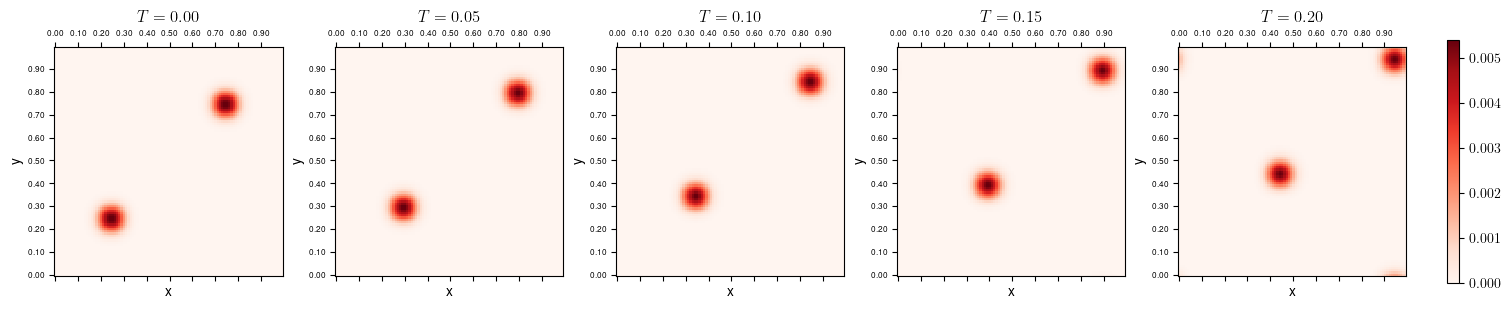

In [140]:
TICK_FONT = 6
LEGEND_FONT = 6
LABEL_FONT = 10
TITLE_FONT = 12

x_tick_labels = []
for i in range(N_high_res):
    x_tick_labels.append(f'{i/N_high_res:.2f}')

# plt.rcParams['font.family'] = 'Helvetica'
fig, axs = plt.subplots(1, num_time_points, constrained_layout=True, facecolor="white", figsize=(15,3))

for j in range(num_time_points):
    # Ideal heatmap
    im = axs[j].matshow(ideal_dist_reshaped[j],
            cmap='Reds',
            origin='lower')
    divider = make_axes_locatable(axs[j])

    # cax = divider.append_axes("right", size="5%", pad=0.05)
    # plt.colorbar(im, cax=cax)
    axs[j].set_xticks(ticks=np.arange(N_high_res)[::10], labels=x_tick_labels[::10], fontsize=TICK_FONT)
    axs[j].set_yticks(ticks=np.arange(N_high_res)[::10], labels=x_tick_labels[::10], fontsize=TICK_FONT)
    axs[j].set_title(rf'$T={t_vals[j]:0.2f}$', fontsize=TITLE_FONT)
    axs[j].set_xlabel('x', fontsize=LABEL_FONT)
    axs[j].set_ylabel('y', fontsize=LABEL_FONT)
# plt.suptitle("Numerical simulation")
fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.9, pad=0.03)
plt.savefig("advection_numerical.png", dpi=300)


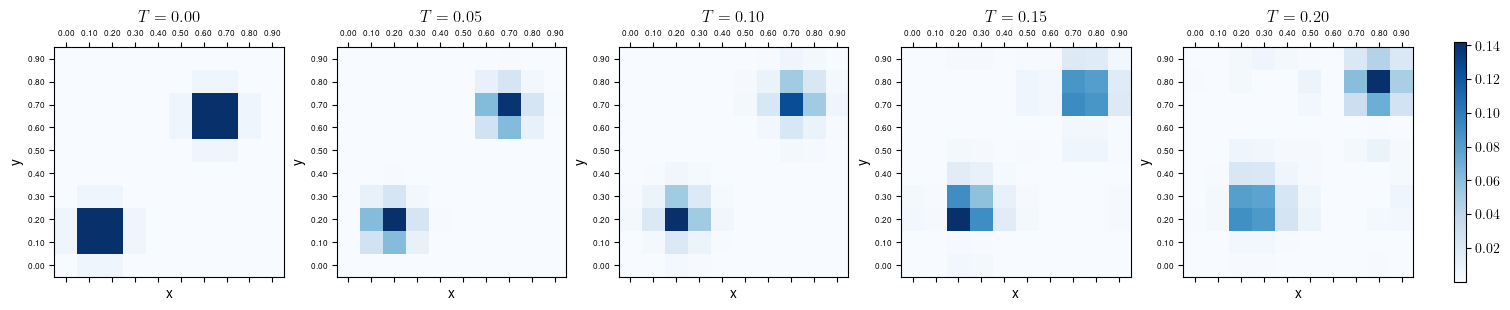

In [12]:
TICK_FONT = 6
LEGEND_FONT = 6
LABEL_FONT = 10
TITLE_FONT = 12

x_tick_labels = []
for i in range(N):
    x_tick_labels.append(f'{i/N:.2f}')

# plt.rcParams['font.family'] = 'Helvetica'
fig, axs = plt.subplots(1, num_time_points, constrained_layout=True, facecolor="white", figsize=(15,3))

for j in range(num_time_points):
    # Ideal heatmap
    im = axs[j].matshow(np.reshape(freq_ideal_sim[j], (N,N)),
            cmap='Blues',
            origin='lower')
    divider = make_axes_locatable(axs[j])

    # cax = divider.append_axes("right", size="5%", pad=0.05)
    # plt.colorbar(im, cax=cax)
    axs[j].set_xticks(ticks=np.arange(N), labels=x_tick_labels, fontsize=TICK_FONT)
    axs[j].set_yticks(ticks=np.arange(N), labels=x_tick_labels, fontsize=TICK_FONT)
    axs[j].set_title(rf'$T={t_vals[j]:0.2f}$', fontsize=TITLE_FONT)
    axs[j].set_xlabel('x', fontsize=LABEL_FONT)
    axs[j].set_ylabel('y', fontsize=LABEL_FONT)
fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.9, pad=0.03)
plt.savefig("advection_ideal_sim.png", dpi=300)


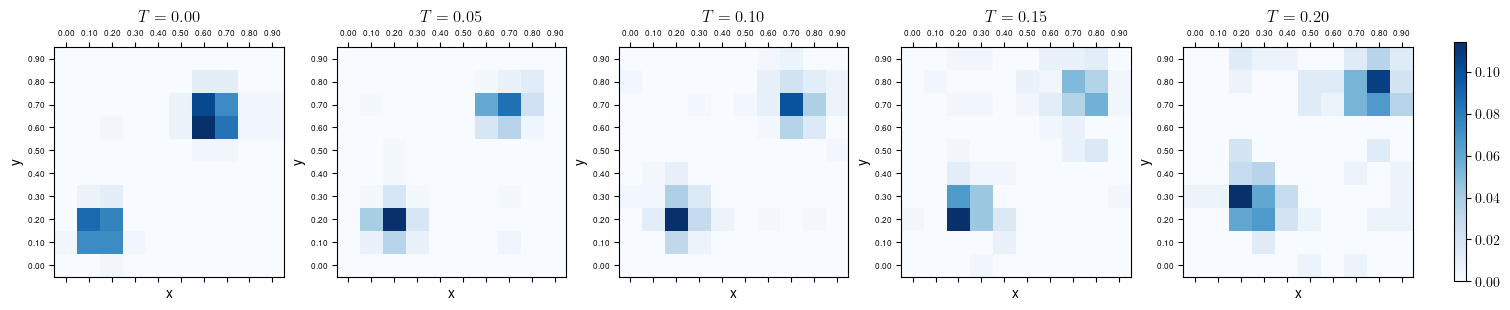

In [14]:
TICK_FONT = 6
LEGEND_FONT = 6
LABEL_FONT = 10
TITLE_FONT = 12

x_tick_labels = []
for i in range(N):
    x_tick_labels.append(f'{i/N:.2f}')

# plt.rcParams['font.family'] = 'Helvetica'
fig, axs = plt.subplots(1, num_time_points, constrained_layout=True, facecolor="white", figsize=(15,3))

for j in range(num_time_points):
    # Ideal heatmap
    im = axs[j].matshow(np.reshape(freq_qpu[j], (N,N)) / np.sum(freq_qpu[j]),
            cmap='Blues',
            origin='lower')
    divider = make_axes_locatable(axs[j])

    # cax = divider.append_axes("right", size="5%", pad=0.05)
    # plt.colorbar(im, cax=cax)
    axs[j].set_xticks(ticks=np.arange(N), labels=x_tick_labels, fontsize=TICK_FONT)
    axs[j].set_yticks(ticks=np.arange(N), labels=x_tick_labels, fontsize=TICK_FONT)
    axs[j].set_title(rf'$T={t_vals[j]:0.2f}$', fontsize=TITLE_FONT)
    axs[j].set_xlabel('x', fontsize=LABEL_FONT)
    axs[j].set_ylabel('y', fontsize=LABEL_FONT)
fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.9, pad=0.03)
plt.savefig("advection_qpu.png", dpi=300)


Resource analysis

In [17]:
std_binary_data = np.load("../data/2d_advection/std_binary_second_order.npz")
N_vals_binary = std_binary_data["N_vals_binary"]
binary_trotter_steps = std_binary_data["binary_trotter_steps"]
binary_one_qubit_gate_count_per_trotter_step = std_binary_data["binary_one_qubit_gate_count_per_trotter_step"]
binary_two_qubit_gate_count_per_trotter_step = std_binary_data["binary_two_qubit_gate_count_per_trotter_step"]
binary_gate_count = binary_trotter_steps * (binary_one_qubit_gate_count_per_trotter_step + binary_two_qubit_gate_count_per_trotter_step)
binary_fit = np.polyfit(np.log(N_vals_binary), np.log(binary_gate_count), deg=1)

bell_basis_data = np.load("../data/2d_advection/bell_basis_second_order.npz")
n_vals_bell_basis = bell_basis_data["n_vals_bell_basis"]
N_vals_bell_basis = bell_basis_data["N_vals_bell_basis"]
bell_basis_trotter_steps = bell_basis_data["bell_basis_trotter_steps"]
bell_basis_one_qubit_gate_count_per_trotter_step = bell_basis_data["bell_basis_one_qubit_gate_count_per_trotter_step"]
bell_basis_two_qubit_gate_count_per_trotter_step = bell_basis_data["bell_basis_two_qubit_gate_count_per_trotter_step"]
bell_basis_gate_count = bell_basis_trotter_steps * (bell_basis_one_qubit_gate_count_per_trotter_step + bell_basis_two_qubit_gate_count_per_trotter_step)
bell_basis_fit = np.polyfit(np.log(N_vals_bell_basis[1:]), np.log(bell_basis_gate_count[1:]), deg=1)

one_hot_data = np.load("../data/2d_advection/one_hot_second_order.npz")
N_vals_one_hot = one_hot_data["N_vals_one_hot"]
one_hot_trotter_steps = one_hot_data["one_hot_trotter_steps"]
one_hot_one_qubit_gate_count_per_trotter_step = one_hot_data["one_hot_one_qubit_gate_count_per_trotter_step"]
one_hot_two_qubit_gate_count_per_trotter_step = one_hot_data["one_hot_two_qubit_gate_count_per_trotter_step"]
one_hot_gate_count = one_hot_trotter_steps * (one_hot_one_qubit_gate_count_per_trotter_step + one_hot_two_qubit_gate_count_per_trotter_step)
one_hot_fit = np.polyfit(np.log(N_vals_one_hot), np.log(one_hot_gate_count), deg=1)

unary_data = np.load("../data/2d_advection/unary_second_order.npz")
N_vals_unary = unary_data["N_vals_unary"]
unary_trotter_steps = unary_data["unary_trotter_steps"]
unary_one_qubit_gate_count_per_trotter_step = unary_data["unary_one_qubit_gate_count_per_trotter_step"]
unary_two_qubit_gate_count_per_trotter_step = unary_data["unary_two_qubit_gate_count_per_trotter_step"]
unary_gate_count = unary_trotter_steps * (unary_one_qubit_gate_count_per_trotter_step + unary_two_qubit_gate_count_per_trotter_step)
unary_fit = np.polyfit(np.log(N_vals_unary[3:]), np.log(unary_gate_count[3:]), deg=1)

In [18]:
# Standard binary
plot_indices = []
for i in range(len(N_vals_binary)):
    if np.log2(N_vals_binary[i]).is_integer():
        k = 2 ** (np.log2(N_vals_binary[i]) - 2)
        seen = 0
        # print(k)
    if np.log2(N_vals_binary[i]) <= 3:
        # Include all points
        plot_indices.append(i)
    else:
        # Include every k points
        if seen % k == 0:
            plot_indices.append(i)
        seen += 1

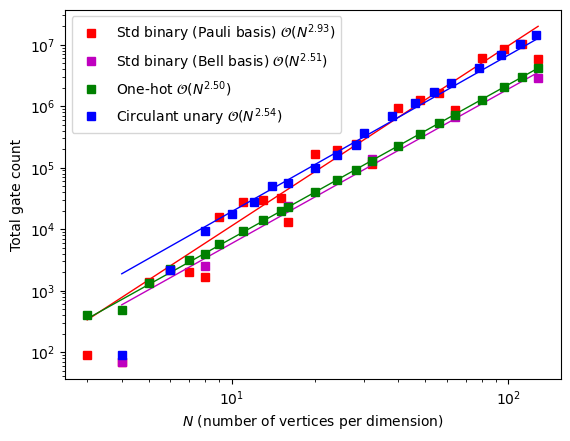

In [19]:
TICK_FONT = 5
LEGEND_FONT = 7
LABEL_FONT = 7
TITLE_FONT = 8

plt.plot(N_vals_binary[plot_indices], binary_gate_count[plot_indices], 's', color='red', label=fr"Std binary (Pauli basis) $\mathcal{{O}}\left(N^{{{binary_fit[0]:0.2f}}}\right)$")
plt.plot(N_vals_binary, np.exp(binary_fit[1]) * N_vals_binary ** (binary_fit[0]), 'r-', linewidth=1)

plt.plot(N_vals_bell_basis, bell_basis_gate_count, 's', color='m', label=fr"Std binary (Bell basis) $\mathcal{{O}}\left(N^{{{bell_basis_fit[0]:0.2f}}}\right)$")
plt.plot(N_vals_bell_basis, np.exp(bell_basis_fit[1]) * N_vals_bell_basis ** (bell_basis_fit[0]), 'm-', linewidth=1)

plt.plot(N_vals_one_hot[plot_indices], one_hot_gate_count[plot_indices], 's', color='g', label=rf"One-hot $\mathcal{{O}}\left(N^{{{one_hot_fit[0]:0.2f}}}\right)$")
plt.plot(N_vals_one_hot, np.exp(one_hot_fit[1]) * N_vals_one_hot ** (one_hot_fit[0]), 'g-', linewidth=1)

plt.plot(N_vals_unary[plot_indices[:-4]], unary_gate_count[plot_indices[:-4]], 's', color='b', label=rf"Circulant unary $\mathcal{{O}}\left(N^{{{unary_fit[0]:0.2f}}}\right)$")
plt.plot(N_vals_unary, np.exp(unary_fit[1]) * N_vals_unary ** (unary_fit[0]), 'b-', linewidth=1)

plt.yscale("log")
plt.xscale("log")
plt.xlabel(rf"$N$ (number of vertices per dimension)")
plt.ylabel("Total gate count")
plt.legend()
plt.savefig("advection_resource_analysis.png", dpi=300, bbox_inches='tight')
plt.show()